# March Madness 2026 Prediction Model

**DTSC 2302 — Project 2**

This notebook builds a machine learning model to predict the 2026 NCAA Men's Basketball Tournament using historical game data from the Kaggle *March Machine Learning Mania* competition.

**Table of Contents**
1. [Setup & Data Loading](#1)
2. [Exploratory Data Analysis](#2)
3. [Feature Engineering](#3)
4. [Train / Validation / Test Split](#4)
5. [Model Training & Comparison](#5)
6. [Feature Importance](#6)
7. [2026 Tournament Predictions](#7)
8. [Results vs. Actuals](#8)

---
## 1. Setup & Data Loading <a id='1'></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, log_loss, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA = '../data/raw/'
print('Libraries loaded.')

Libraries loaded.


In [3]:
# ── Load core datasets ──────────────────────────────────────────────────────
teams       = pd.read_csv(DATA + 'MTeams.csv')
seeds       = pd.read_csv(DATA + 'MNCAATourneySeeds.csv')
reg_detail  = pd.read_csv(DATA + 'MRegularSeasonDetailedResults.csv')
tourn       = pd.read_csv(DATA + 'MNCAATourneyDetailedResults.csv')
massey      = pd.read_csv(DATA + 'MMasseyOrdinals.csv')

print('Teams:          ', teams.shape)
print('Seeds:          ', seeds.shape)
print('Reg Season:     ', reg_detail.shape)
print('Tournament:     ', tourn.shape)
print('Massey Ordinals:', massey.shape)

Teams:           (381, 4)
Seeds:           (2694, 3)
Reg Season:      (124529, 34)
Tournament:      (1449, 34)
Massey Ordinals: (5865001, 5)


In [4]:
# ── Quick peek at key tables ─────────────────────────────────────────────────
print('=== Seeds (first 5) ===')
display(seeds.head())

print('\n=== Regular Season Detailed (first 3 rows, first 15 cols) ===')
display(reg_detail.iloc[:3, :15])

print('\n=== Tournament Results (first 3 rows) ===')
display(tourn.head(3))

print('\n=== Massey Ordinals — unique systems ===')
print(massey['SystemName'].unique()[:20])

=== Seeds (first 5) ===


,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374



=== Regular Season Detailed (first 3 rows, first 15 cols) ===


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17



=== Tournament Results (first 3 rows) ===


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,...,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,...,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,...,28,14,21,20,22,11,12,2,5,18



=== Massey Ordinals — unique systems ===
['SEL' 'AP' 'BIH' 'DUN' 'ENT' 'GRN' 'IMS' 'MAS' 'MKV' 'MOR' 'POM' 'RPI'
 'SAG' 'SAU' 'SE' 'STR' 'USA' 'WLK' 'WOB' 'BOB']


---
## 2. Exploratory Data Analysis <a id='2'></a>

In [5]:
# ── Helper: parse numeric seed from strings like 'W01', 'Z16a' ──────────────
def parse_seed(s):
    return int(''.join(filter(str.isdigit, s)))

seeds['SeedNum'] = seeds['Seed'].apply(parse_seed)

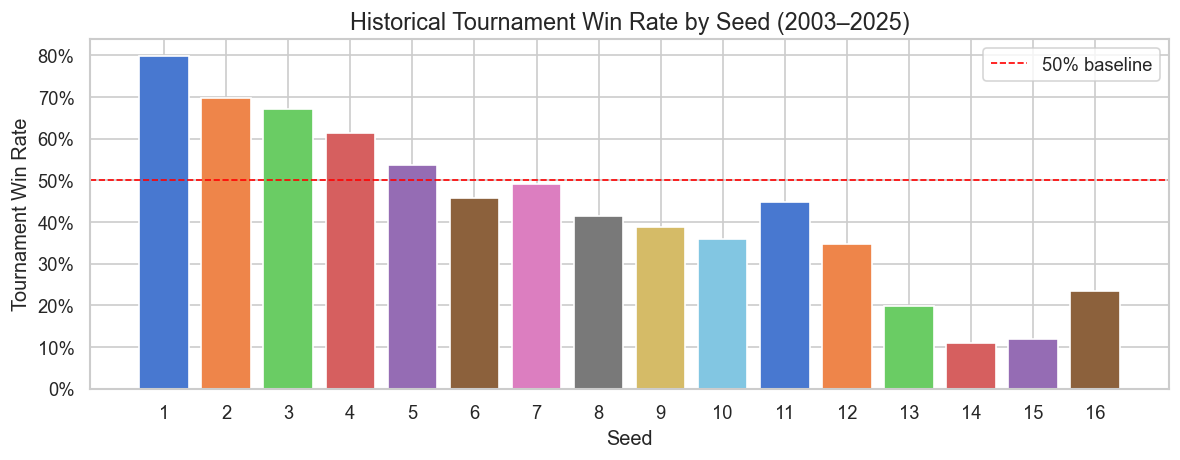

In [6]:
# ── Win rates by seed (2003–2025, all rounds) ────────────────────────────────
# Attach seeds for winner and loser
t = tourn[tourn['Season'] <= 2025].copy()
t = t.merge(seeds[['Season','TeamID','SeedNum']].rename(columns={'TeamID':'WTeamID','SeedNum':'WSeed'}),
            on=['Season','WTeamID'], how='left')
t = t.merge(seeds[['Season','TeamID','SeedNum']].rename(columns={'TeamID':'LTeamID','SeedNum':'LSeed'}),
            on=['Season','LTeamID'], how='left')

# Games won per seed
wins   = t.groupby('WSeed').size().rename('wins')
losses = t.groupby('LSeed').size().rename('losses')
wins.index.name   = 'seed'
losses.index.name = 'seed'
seed_perf = pd.concat([wins, losses], axis=1).fillna(0).reset_index()
seed_perf['total']   = seed_perf['wins'] + seed_perf['losses']
seed_perf['win_pct'] = seed_perf['wins'] / seed_perf['total']
seed_perf = seed_perf[seed_perf['seed'] <= 16].sort_values('seed')

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(seed_perf['seed'], seed_perf['win_pct'], color=sns.color_palette('muted', 16))
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% baseline')
ax.set_xlabel('Seed', fontsize=12)
ax.set_ylabel('Tournament Win Rate', fontsize=12)
ax.set_title('Historical Tournament Win Rate by Seed (2003–2025)', fontsize=14)
ax.set_xticks(range(1, 17))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

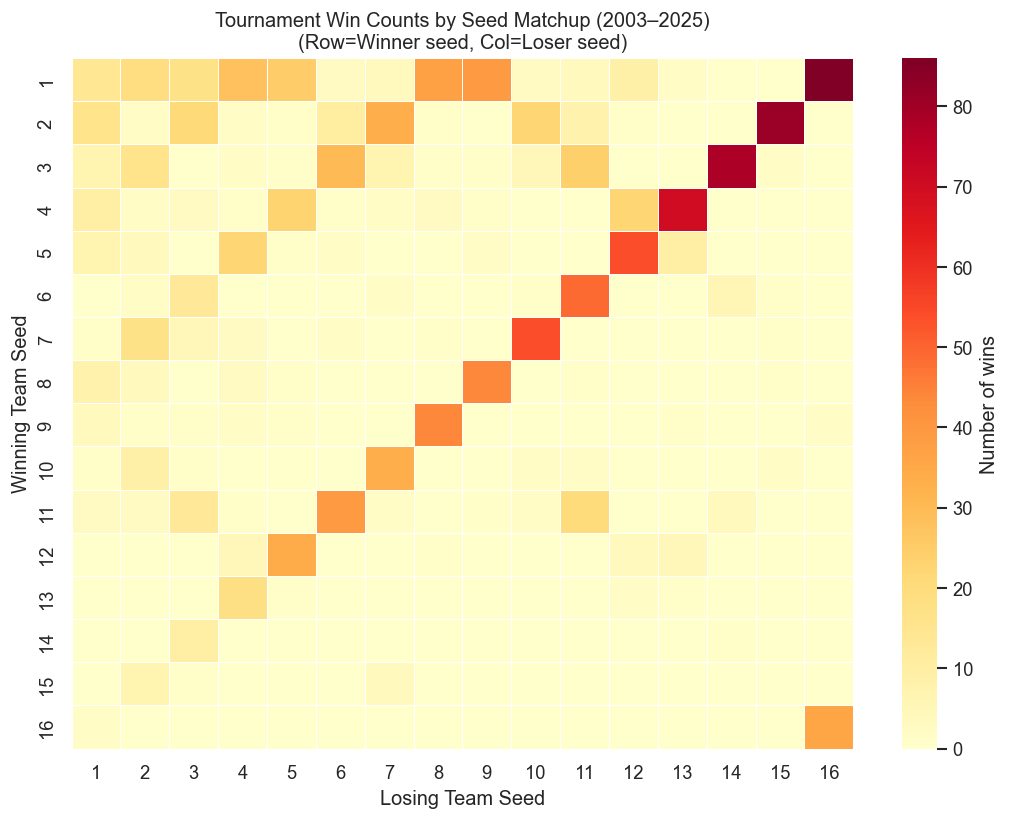

In [7]:
# ── Seed matchup upset heatmap: P(lower seed wins) given (winner_seed, loser_seed) ──
# Build a pivot: rows = winner seed, cols = loser seed, value = # times it happened
seed_matchup = t.groupby(['WSeed','LSeed']).size().reset_index(name='count')

# Only look at matchups where winner was the 'underdog' (higher seed number)
upsets = seed_matchup[seed_matchup['WSeed'] > seed_matchup['LSeed']]
total_matchups = t.groupby(['WSeed','LSeed']).size().reset_index(name='count')

# Compute upset rate per matchup type (limit to seeds 1-16)
pivot_wins  = t[t['WSeed'] <= 16][t['LSeed'] <= 16].groupby(['WSeed','LSeed']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pivot_wins.iloc[:16, :16], cmap='YlOrRd', ax=ax,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Number of wins'})
ax.set_title('Tournament Win Counts by Seed Matchup (2003–2025)\n(Row=Winner seed, Col=Loser seed)', fontsize=12)
ax.set_xlabel('Losing Team Seed')
ax.set_ylabel('Winning Team Seed')
plt.tight_layout()
plt.show()

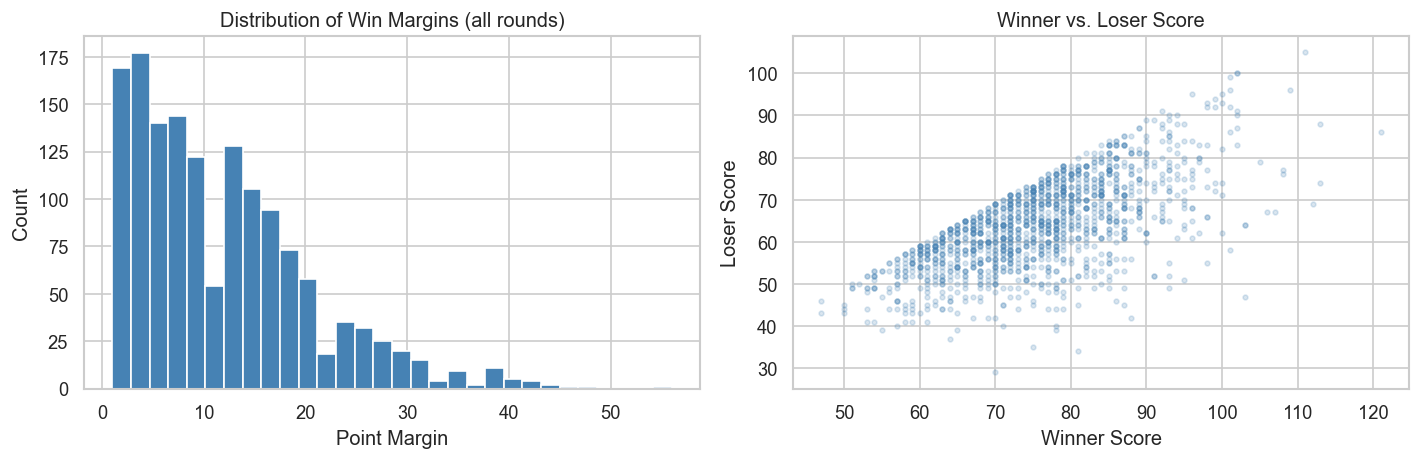

Median win margin: 10.0 pts
Mean win margin:   11.7 pts
Games decided by ≤5 pts: 28.9%


In [8]:
# ── Distribution of point margins in the tournament ──────────────────────────
t['margin'] = t['WScore'] - t['LScore']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(t['margin'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Win Margins (all rounds)')
axes[0].set_xlabel('Point Margin')
axes[0].set_ylabel('Count')

# Score correlation
axes[1].scatter(t['WScore'], t['LScore'], alpha=0.2, s=8, color='steelblue')
axes[1].set_title('Winner vs. Loser Score')
axes[1].set_xlabel('Winner Score')
axes[1].set_ylabel('Loser Score')

plt.tight_layout()
plt.show()

print(f"Median win margin: {t['margin'].median():.1f} pts")
print(f"Mean win margin:   {t['margin'].mean():.1f} pts")
print(f"Games decided by ≤5 pts: {(t['margin'] <= 5).mean():.1%}")

---
## 3. Feature Engineering <a id='3'></a>

We compute per-team season-level statistics using **only regular-season games**.
For each tournament matchup, the feature vector is the **difference** between the two teams' stats (Team A − Team B).  
Every game is added twice (A vs B and B vs A) so the model sees both perspectives.

**Features built:**
- Win percentage
- Offensive efficiency (pts per possession)
- Defensive efficiency (opp pts per possession)
- Effective FG% (eFG%)
- Turnover rate
- Offensive rebound rate
- Free throw rate
- Strength of schedule (avg opponent win%)
- KenPom rank (from Massey Ordinals)
- Seed number

In [9]:
# ── Step 1: Build team season stats from regular season box scores ─────────

def build_team_stats(reg_df):
    """
    Returns one row per (Season, TeamID) with aggregated regular-season stats.
    Processes both winner and loser perspectives from each game row.
    """
    # Winner perspective
    w = reg_df.rename(columns={
        'WTeamID': 'TeamID', 'LTeamID': 'OppID',
        'WScore': 'Pts',   'LScore': 'OppPts',
        'WFGM':  'FGM',    'WFGA':   'FGA',
        'WFGM3': 'FGM3',   'WFGA3':  'FGA3',
        'WFTM':  'FTM',    'WFTA':   'FTA',
        'WOR':   'OR',     'WDR':    'DR',
        'WAst':  'Ast',    'WTO':    'TO',
        'WStl':  'Stl',    'WBlk':   'Blk',
        'WPF':   'PF',
        'LFGM':  'OppFGM', 'LFGA':  'OppFGA',
        'LFGM3': 'OppFGM3','LFGA3': 'OppFGA3',
        'LFTM':  'OppFTM', 'LFTA':  'OppFTA',
        'LOR':   'OppOR',  'LDR':   'OppDR',
        'LAst':  'OppAst', 'LTO':   'OppTO',
    })
    w['Win'] = 1

    # Loser perspective
    l = reg_df.rename(columns={
        'LTeamID': 'TeamID', 'WTeamID': 'OppID',
        'LScore': 'Pts',   'WScore': 'OppPts',
        'LFGM':  'FGM',    'LFGA':   'FGA',
        'LFGM3': 'FGM3',   'LFGA3':  'FGA3',
        'LFTM':  'FTM',    'LFTA':   'FTA',
        'LOR':   'OR',     'LDR':    'DR',
        'LAst':  'Ast',    'LTO':    'TO',
        'LStl':  'Stl',    'LBlk':   'Blk',
        'LPF':   'PF',
        'WFGM':  'OppFGM', 'WFGA':  'OppFGA',
        'WFGM3': 'OppFGM3','WFGA3': 'OppFGA3',
        'WFTM':  'OppFTM', 'WFTA':  'OppFTA',
        'WOR':   'OppOR',  'WDR':   'OppDR',
        'WAst':  'OppAst', 'WTO':   'OppTO',
    })
    l['Win'] = 0

    cols = ['Season','TeamID','OppID','Pts','OppPts','FGM','FGA','FGM3','FGA3',
            'FTM','FTA','OR','DR','TO','OppFGM','OppFGA','OppOR','OppDR','OppTO','Win']
    games = pd.concat([w[cols], l[cols]], ignore_index=True)

    # Aggregate to season level
    agg = games.groupby(['Season','TeamID']).agg(
        Games       = ('Win', 'count'),
        Wins        = ('Win', 'sum'),
        Pts         = ('Pts', 'mean'),
        OppPts      = ('OppPts', 'mean'),
        FGM         = ('FGM', 'mean'),
        FGA         = ('FGA', 'mean'),
        FGM3        = ('FGM3', 'mean'),
        FGA3        = ('FGA3', 'mean'),
        FTA         = ('FTA', 'mean'),
        OR          = ('OR', 'mean'),
        DR          = ('DR', 'mean'),
        TO          = ('TO', 'mean'),
        OppFGM      = ('OppFGM', 'mean'),
        OppFGA      = ('OppFGA', 'mean'),
        OppOR       = ('OppOR', 'mean'),
        OppDR       = ('OppDR', 'mean'),
        OppTO       = ('OppTO', 'mean'),
    ).reset_index()

    agg['WinPct']  = agg['Wins'] / agg['Games']

    # Four Factors (offense)
    agg['eFGPct']  = (agg['FGM'] + 0.5 * agg['FGM3']) / agg['FGA']
    agg['TOVRate'] = agg['TO'] / (agg['FGA'] + 0.44 * agg['FTA'] + agg['TO'])
    agg['ORBRate'] = agg['OR'] / (agg['OR'] + agg['OppDR'])
    agg['FTRate']  = agg['FTA'] / agg['FGA']

    # Efficiency proxies (pts per possession estimate)
    agg['Possessions']    = agg['FGA'] + 0.44 * agg['FTA'] - agg['OR'] + agg['TO']
    agg['OppPossessions'] = agg['OppFGA'] + 0.44 * 0  - agg['OppOR'] + agg['OppTO']  # approx
    agg['OffEff']  = agg['Pts']    / agg['Possessions']  * 100
    agg['DefEff']  = agg['OppPts'] / agg['Possessions']  * 100
    agg['NetEff']  = agg['OffEff'] - agg['DefEff']

    # Defensive four factors
    agg['Def_eFGPct']  = (agg['OppFGM'] + 0.5 * 0) / agg['OppFGA']   # approx (no opp FGM3 split)
    agg['Def_TOVRate'] = agg['OppTO'] / (agg['OppFGA'] + agg['OppTO'])

    keep = ['Season','TeamID','WinPct','OffEff','DefEff','NetEff',
            'eFGPct','TOVRate','ORBRate','FTRate',
            'Def_eFGPct','Def_TOVRate']
    return agg[keep]


team_stats = build_team_stats(reg_detail)
print('Team stats shape:', team_stats.shape)
team_stats.head()

Team stats shape: (8346, 12)


,Season,TeamID,WinPct,OffEff,DefEff,NetEff,eFGPct,TOVRate,ORBRate,FTRate,Def_eFGPct,Def_TOVRate
0,2003,1102,0.428571,104.924857,104.466670,0.458187,0.579443,0.194557,0.171806,0.429982,0.454545,0.234043
1,2003,1103,0.481481,112.413589,111.515126,0.898463,0.534814,0.158154,0.307334,0.462865,0.487329,0.211982
2,2003,1104,0.607143,104.817272,98.333730,6.483543,0.475953,0.166753,0.374753,0.366021,0.418919,0.199794
3,2003,1105,0.269231,93.961489,100.356510,-6.395021,0.457241,0.207538,0.338476,0.354557,0.457926,0.241840
4,2003,1106,0.464286,94.540938,94.753270,-0.212332,0.479005,0.214109,0.354639,0.297804,0.406689,0.220136


In [10]:
# ── Step 2: Strength of Schedule (avg opponent win%) ─────────────────────────

# Build opponent list per team-season
w_opps = reg_detail[['Season','WTeamID','LTeamID']].rename(columns={'WTeamID':'TeamID','LTeamID':'OppID'})
l_opps = reg_detail[['Season','LTeamID','WTeamID']].rename(columns={'LTeamID':'TeamID','WTeamID':'OppID'})
all_opps = pd.concat([w_opps, l_opps], ignore_index=True)

# Merge opponent win% onto each game
all_opps = all_opps.merge(
    team_stats[['Season','TeamID','WinPct']].rename(columns={'TeamID':'OppID','WinPct':'OppWinPct'}),
    on=['Season','OppID'], how='left'
)

sos = all_opps.groupby(['Season','TeamID'])['OppWinPct'].mean().reset_index()
sos.rename(columns={'OppWinPct': 'SOS'}, inplace=True)

team_stats = team_stats.merge(sos, on=['Season','TeamID'], how='left')
print('Team stats with SOS:', team_stats.shape)

Team stats with SOS: (8346, 13)


In [11]:
# ── Step 3: KenPom rank from Massey Ordinals ──────────────────────────────────
# Use the last available ordinal before Selection Sunday (~day 133)

kenpom = massey[
    (massey['SystemName'] == 'KP') &
    (massey['RankingDayNum'] <= 133)
].sort_values('RankingDayNum')

kenpom_latest = (
    kenpom
    .sort_values('RankingDayNum')
    .groupby(['Season','TeamID'])
    .last()
    .reset_index()[['Season','TeamID','OrdinalRank']]
    .rename(columns={'OrdinalRank': 'KenPomRank'})
)

team_stats = team_stats.merge(kenpom_latest, on=['Season','TeamID'], how='left')
print(f"KenPom coverage: {team_stats['KenPomRank'].notna().mean():.1%}")
team_stats.head(3)

KenPom coverage: 0.0%


,Season,TeamID,WinPct,OffEff,DefEff,NetEff,eFGPct,TOVRate,ORBRate,FTRate,Def_eFGPct,Def_TOVRate,SOS,KenPomRank
0,2003,1102,0.428571,104.924857,104.466670,0.458187,0.579443,0.194557,0.171806,0.429982,0.454545,0.234043,0.530644,NaN
1,2003,1103,0.481481,112.413589,111.515126,0.898463,0.534814,0.158154,0.307334,0.462865,0.487329,0.211982,0.489779,NaN
2,2003,1104,0.607143,104.817272,98.333730,6.483543,0.475953,0.166753,0.374753,0.366021,0.418919,0.199794,0.572492,NaN


In [12]:
# ── Step 4: Build matchup dataset from tournament games ───────────────────────

def build_matchups(tourn_df, team_stats_df, seeds_df):
    """
    Returns a DataFrame where each row represents one tournament game.
    Features = (Team A stats) - (Team B stats), plus seed difference.
    Every game appears twice (A vs B and B vs A) for symmetry.
    Target (label) = 1 if Team A won.
    """
    stat_cols = ['WinPct','OffEff','DefEff','NetEff',
                 'eFGPct','TOVRate','ORBRate','FTRate',
                 'Def_eFGPct','Def_TOVRate','SOS','KenPomRank']

    rows = []
    for _, game in tourn_df.iterrows():
        season  = game['Season']
        wteam   = game['WTeamID']
        lteam   = game['LTeamID']

        w_stats = team_stats_df[(team_stats_df['Season'] == season) &
                                 (team_stats_df['TeamID'] == wteam)]
        l_stats = team_stats_df[(team_stats_df['Season'] == season) &
                                 (team_stats_df['TeamID'] == lteam)]

        w_seed_row = seeds_df[(seeds_df['Season'] == season) & (seeds_df['TeamID'] == wteam)]
        l_seed_row = seeds_df[(seeds_df['Season'] == season) & (seeds_df['TeamID'] == lteam)]

        if w_stats.empty or l_stats.empty or w_seed_row.empty or l_seed_row.empty:
            continue

        w_s = w_stats.iloc[0]
        l_s = l_stats.iloc[0]
        w_seed = w_seed_row.iloc[0]['SeedNum']
        l_seed = l_seed_row.iloc[0]['SeedNum']

        # Winner perspective (label=1)
        feat_w = {col + '_diff': w_s[col] - l_s[col] for col in stat_cols}
        feat_w['SeedDiff'] = w_seed - l_seed
        feat_w['label']    = 1
        feat_w['Season']   = season
        rows.append(feat_w)

        # Loser perspective (label=0, flip signs)
        feat_l = {col + '_diff': l_s[col] - w_s[col] for col in stat_cols}
        feat_l['SeedDiff'] = l_seed - w_seed
        feat_l['label']    = 0
        feat_l['Season']   = season
        rows.append(feat_l)

    return pd.DataFrame(rows)


matchups = build_matchups(tourn, team_stats, seeds)
print('Matchup dataset shape:', matchups.shape)
print('Label distribution:')
print(matchups['label'].value_counts())
matchups.head(3)

Matchup dataset shape: (2898, 15)
Label distribution:
label
1    1449
0    1449
Name: count, dtype: int64


,WinPct_diff,OffEff_diff,DefEff_diff,NetEff_diff,eFGPct_diff,TOVRate_diff,ORBRate_diff,FTRate_diff,Def_eFGPct_diff,Def_TOVRate_diff,SOS_diff,KenPomRank_diff,SeedDiff,label,Season
0,-0.151724,-2.653173,10.523767,-13.176939,-0.014867,0.013273,-0.015697,-0.139292,0.030938,-0.017961,0.104891,NaN,0,1,2003
1,0.151724,2.653173,-10.523767,13.176939,0.014867,-0.013273,0.015697,0.139292,-0.030938,0.017961,-0.104891,NaN,0,0,2003
2,0.237685,8.258702,-4.248491,12.507193,0.023279,-0.017553,0.022337,0.030435,-0.005765,0.015763,0.114559,NaN,-15,1,2003


---
## 4. Train / Validation / Test Split <a id='4'></a>

| Split | Seasons | Purpose |
|-------|---------|--------|
| **Train** | 2003–2023 | Fit all models |
| **Validation** | 2024 | Tune + compare models |
| **Test** | 2025 | Final held-out evaluation |
| **Predict** | 2026 | Live bracket predictions |

In [13]:
feature_cols = [c for c in matchups.columns if c not in ['label','Season']]

train_df = matchups[matchups['Season'] <= 2023].copy()
val_df   = matchups[matchups['Season'] == 2024].copy()
test_df  = matchups[matchups['Season'] == 2025].copy()

# Impute NaN: median from train, fallback to 0 if median itself is NaN
medians = train_df[feature_cols].median()
medians = medians.fillna(0)

train_df[feature_cols] = train_df[feature_cols].fillna(medians)
val_df[feature_cols]   = val_df[feature_cols].fillna(medians)
test_df[feature_cols]  = test_df[feature_cols].fillna(medians)

X_train, y_train = train_df[feature_cols].values, train_df['label'].values
X_val,   y_val   = val_df[feature_cols].values,   val_df['label'].values
X_test,  y_test  = test_df[feature_cols].values,  test_df['label'].values

print(f'Train:      {X_train.shape[0]:,} rows ({y_train.mean():.0%} wins)')
print(f'Validation: {X_val.shape[0]:,} rows')
print(f'Test:       {X_test.shape[0]:,} rows')
print(f'NaN in X_train: {np.isnan(X_train).sum()}')

# Scaler for distance/linear models
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

Train:      2,630 rows (50% wins)
Validation: 134 rows
Test:       134 rows
NaN in X_train: 0


---
## 5. Model Training & Comparison <a id='5'></a>

In [14]:
models = {
    'Logistic Regression': (LogisticRegression(C=1.0, max_iter=1000, random_state=42), True),
    'K-Nearest Neighbors': (KNeighborsClassifier(n_neighbors=11), True),
    'Random Forest':       (RandomForestClassifier(n_estimators=300, max_depth=6,
                                                    random_state=42), False),
    'XGBoost':             (XGBClassifier(n_estimators=300, learning_rate=0.05,
                                          max_depth=4, subsample=0.8,
                                          eval_metric='logloss',
                                          random_state=42), False),
}
# Second element = whether the model needs scaled features

results = {}
trained = {}

for name, (model, needs_scale) in models.items():
    Xtr = X_train_s if needs_scale else X_train
    Xv  = X_val_s   if needs_scale else X_val

    model.fit(Xtr, y_train)
    preds      = model.predict(Xv)
    probs      = model.predict_proba(Xv)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_val, preds),
        'Log Loss': log_loss(y_val, probs),
        'ROC-AUC':  roc_auc_score(y_val, probs),
    }
    trained[name] = model
    print(f"{name:<25}  Acc={results[name]['Accuracy']:.3f}  "
          f"LogLoss={results[name]['Log Loss']:.3f}  "
          f"AUC={results[name]['ROC-AUC']:.3f}")

Logistic Regression        Acc=0.672  LogLoss=0.569  AUC=0.764
K-Nearest Neighbors        Acc=0.567  LogLoss=0.631  AUC=0.655
Random Forest              Acc=0.694  LogLoss=0.565  AUC=0.769
XGBoost                    Acc=0.642  LogLoss=0.631  AUC=0.720


In [15]:
# ── Summary comparison table ──────────────────────────────────────────────────
results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
results_df = results_df.round(4)
print('=== Validation Set Performance ===')
display(results_df.style.background_gradient(subset=['Accuracy','ROC-AUC'], cmap='Greens')
                        .background_gradient(subset=['Log Loss'], cmap='Reds_r'))

=== Validation Set Performance ===


,Accuracy,Log Loss,ROC-AUC
Random Forest,0.694000,0.564900,0.768500
Logistic Regression,0.671600,0.569200,0.764300
XGBoost,0.641800,0.631100,0.720400
K-Nearest Neighbors,0.567200,0.631300,0.654900


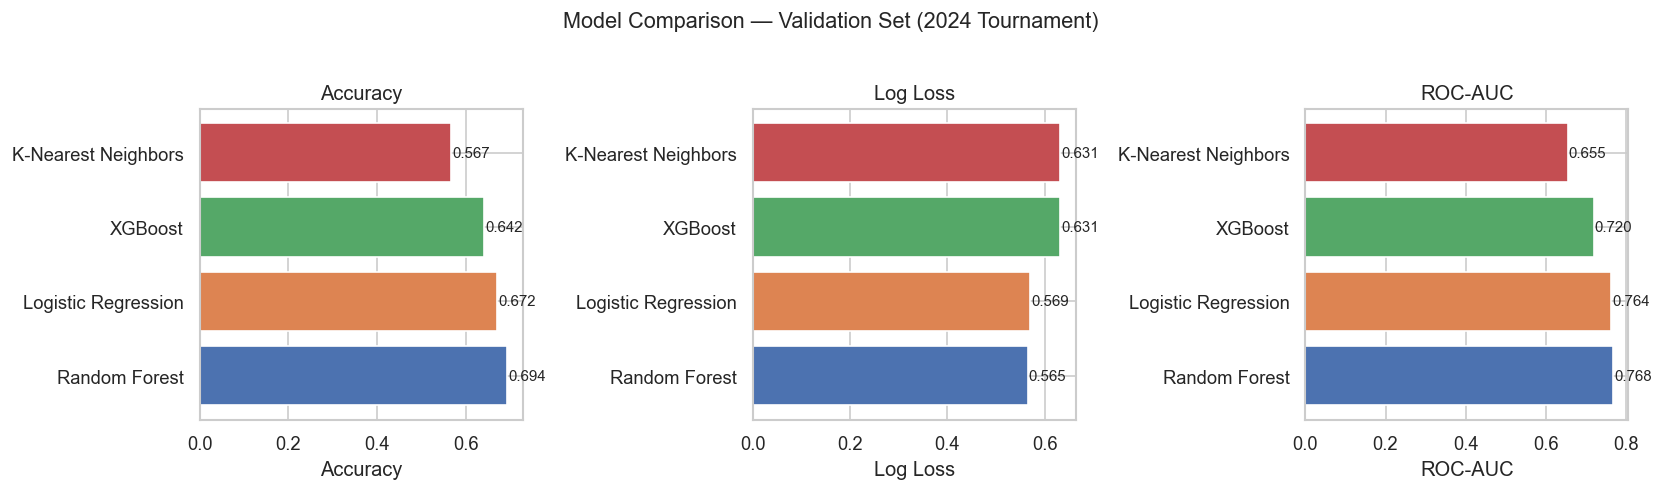

In [16]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['Accuracy', 'Log Loss', 'ROC-AUC']
colors  = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

for ax, metric in zip(axes, metrics):
    vals   = results_df[metric]
    sorted_vals = vals.sort_values(ascending=(metric == 'Log Loss'))
    bars = ax.barh(sorted_vals.index, sorted_vals.values, color=colors)
    ax.set_title(metric)
    ax.set_xlabel(metric)
    for bar, v in zip(bars, sorted_vals.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — Validation Set (2024 Tournament)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

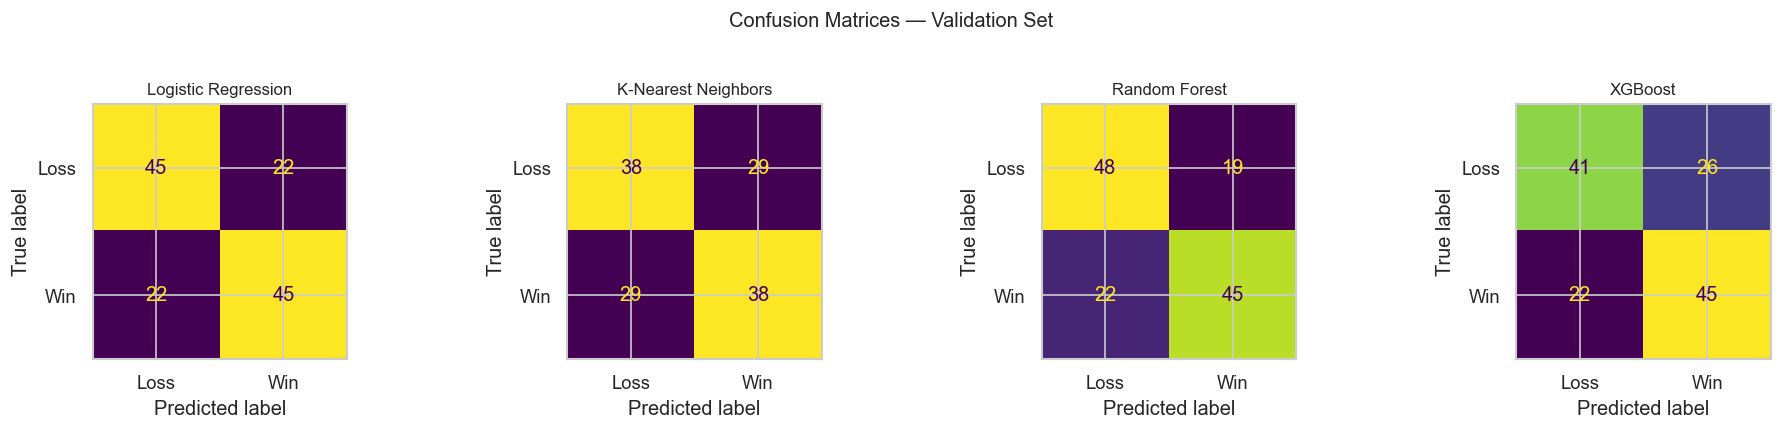

In [17]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for ax, (name, (model, needs_scale)) in zip(axes, models.items()):
    Xv = X_val_s if needs_scale else X_val
    cm = confusion_matrix(y_val, trained[name].predict(Xv))
    ConfusionMatrixDisplay(cm, display_labels=['Loss', 'Win']).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)

plt.suptitle('Confusion Matrices — Validation Set', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# ── Test set evaluation (2025 tournament) ────────────────────────────────────
print('=== HELD-OUT TEST SET — 2025 Tournament ===')
for name, (model, needs_scale) in models.items():
    Xt = X_test_s if needs_scale else X_test
    preds = model.predict(Xt)
    probs = model.predict_proba(Xt)[:, 1]
    print(f"{name:<25}  Acc={accuracy_score(y_test, preds):.3f}  "
          f"LogLoss={log_loss(y_test, probs):.3f}  "
          f"AUC={roc_auc_score(y_test, probs):.3f}")

=== HELD-OUT TEST SET — 2025 Tournament ===
Logistic Regression        Acc=0.761  LogLoss=0.470  AUC=0.869
K-Nearest Neighbors        Acc=0.851  LogLoss=0.441  AUC=0.881
Random Forest              Acc=0.739  LogLoss=0.468  AUC=0.883
XGBoost                    Acc=0.754  LogLoss=0.477  AUC=0.848


---
## 6. Feature Importance <a id='6'></a>

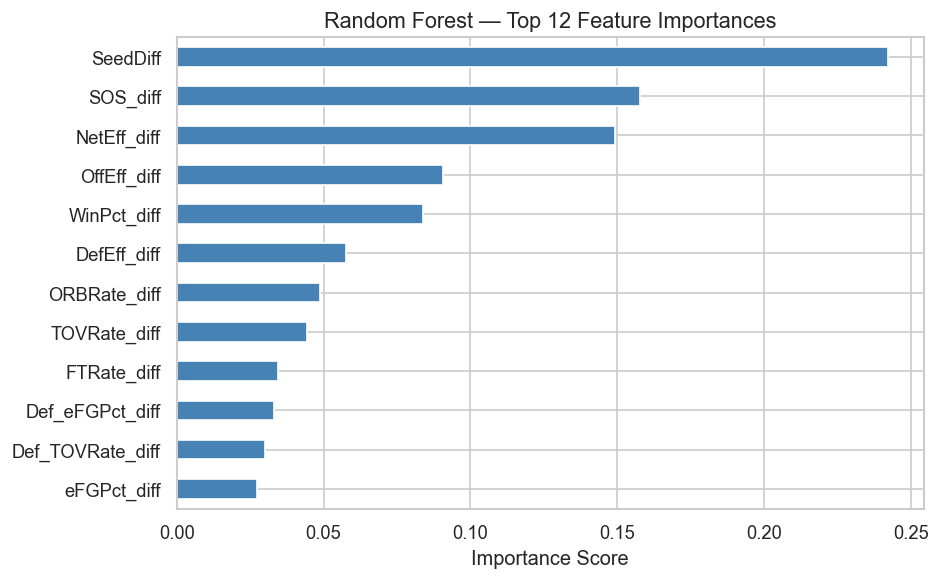

In [19]:
# ── Random Forest importance ──────────────────────────────────────────────────
rf_model = trained['Random Forest']
rf_imp   = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
rf_imp.tail(12).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Top 12 Feature Importances', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

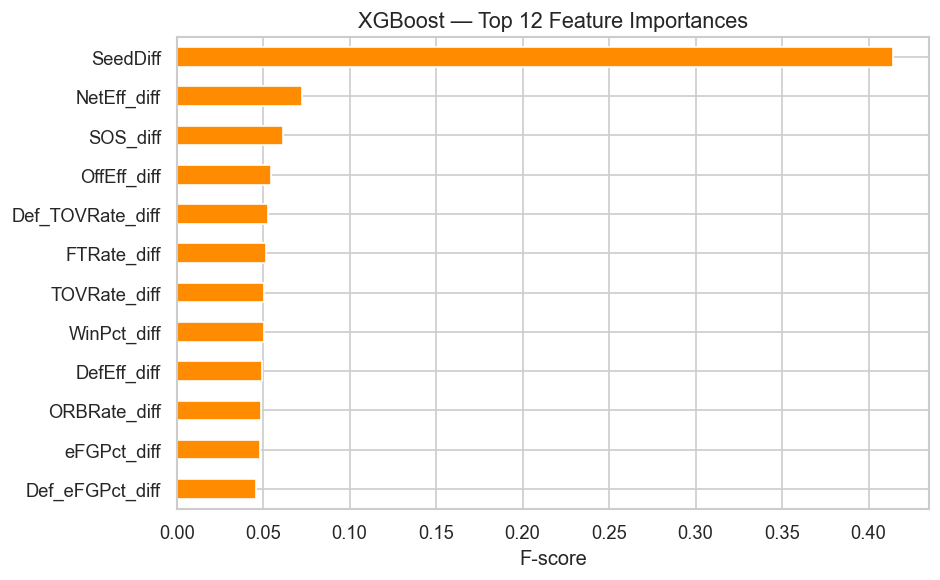

In [20]:
# ── XGBoost importance ────────────────────────────────────────────────────────
xgb_model = trained['XGBoost']
xgb_imp   = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
xgb_imp.tail(12).plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('XGBoost — Top 12 Feature Importances', fontsize=13)
ax.set_xlabel('F-score')
plt.tight_layout()
plt.show()

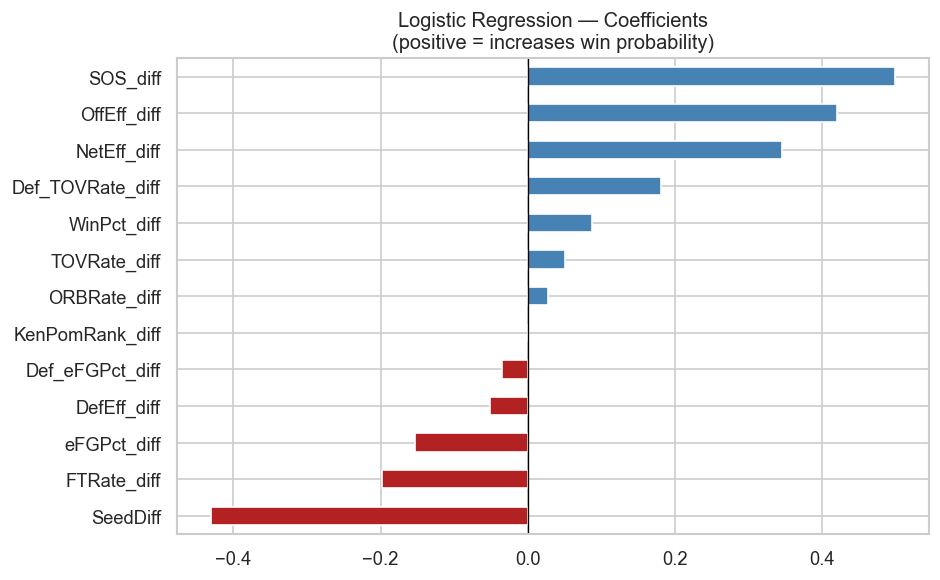

In [21]:
# ── Logistic Regression coefficients ─────────────────────────────────────────
lr_model = trained['Logistic Regression']
lr_coefs = pd.Series(lr_model.coef_[0], index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_lr = ['firebrick' if c < 0 else 'steelblue' for c in lr_coefs.values]
lr_coefs.plot(kind='barh', ax=ax, color=colors_lr)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Coefficients\n(positive = increases win probability)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 7. 2026 Tournament Predictions <a id='7'></a>

We use the **best-performing model** (by validation log loss) to predict the 2026 tournament.  
Predictions are made by simulating each round in sequence.

In [22]:
# ── Select best model ─────────────────────────────────────────────────────────
best_model_name = results_df['Log Loss'].idxmin()
print(f'Best model (lowest log loss on validation): {best_model_name}')

best_model_obj, best_needs_scale = models[best_model_name]

Best model (lowest log loss on validation): Random Forest


In [23]:
# ── Build 2026 team stats ─────────────────────────────────────────────────────
reg_2026    = reg_detail[reg_detail['Season'] == 2026]
stats_2026  = build_team_stats(reg_2026)

# SOS for 2026
w_opps_26 = reg_2026[['Season','WTeamID','LTeamID']].rename(columns={'WTeamID':'TeamID','LTeamID':'OppID'})
l_opps_26 = reg_2026[['Season','LTeamID','WTeamID']].rename(columns={'LTeamID':'TeamID','WTeamID':'OppID'})
all_opps_26 = pd.concat([w_opps_26, l_opps_26], ignore_index=True)
all_opps_26 = all_opps_26.merge(
    stats_2026[['Season','TeamID','WinPct']].rename(columns={'TeamID':'OppID','WinPct':'OppWinPct'}),
    on=['Season','OppID'], how='left'
)
sos_26 = all_opps_26.groupby(['Season','TeamID'])['OppWinPct'].mean().reset_index().rename(columns={'OppWinPct':'SOS'})
stats_2026 = stats_2026.merge(sos_26, on=['Season','TeamID'], how='left')

# KenPom 2026
kp_26 = massey[(massey['SystemName'] == 'KP') & (massey['Season'] == 2026) & (massey['RankingDayNum'] <= 133)]
kp_26 = kp_26.sort_values('RankingDayNum').groupby('TeamID').last().reset_index()[['TeamID','OrdinalRank']]
kp_26['Season'] = 2026
kp_26.rename(columns={'OrdinalRank':'KenPomRank'}, inplace=True)
stats_2026 = stats_2026.merge(kp_26[['Season','TeamID','KenPomRank']], on=['Season','TeamID'], how='left')

print('2026 team stats:', stats_2026.shape)

2026 team stats: (365, 14)


In [24]:
# ── 2026 seeds ────────────────────────────────────────────────────────────────
seeds_2026 = seeds[seeds['Season'] == 2026].copy()

if seeds_2026.empty:
    print('WARNING: 2026 seeds not yet in Kaggle dataset.')
    print('You can manually create seeds_2026 once the bracket is released:')
    print("""
    seeds_2026 = pd.DataFrame([
        {'Season': 2026, 'TeamID': <id>, 'Seed': 'W01', 'SeedNum': 1},
        ...  # one row per team
    ])
    """)
else:
    print(f'2026 seeds loaded: {seeds_2026.shape[0]} teams')
    display(seeds_2026.head())

2026 seeds loaded: 68 teams


,Season,Seed,TeamID,SeedNum
2626,2026,W01,1181,1
2627,2026,W02,1163,2
2628,2026,W03,1277,3
2629,2026,W04,1242,4
2630,2026,W05,1385,5


In [25]:
# ── Predict a single game ─────────────────────────────────────────────────────

def predict_game(team_a_id, team_b_id, season, team_stats_df, seeds_df, model, needs_scale, scaler):
    """
    Returns (win_prob_a, win_prob_b) for a head-to-head matchup.
    Returns None if stats are missing.
    """
    stat_cols = ['WinPct','OffEff','DefEff','NetEff',
                 'eFGPct','TOVRate','ORBRate','FTRate',
                 'Def_eFGPct','Def_TOVRate','SOS','KenPomRank']

    a_stats = team_stats_df[(team_stats_df['Season'] == season) & (team_stats_df['TeamID'] == team_a_id)]
    b_stats = team_stats_df[(team_stats_df['Season'] == season) & (team_stats_df['TeamID'] == team_b_id)]
    a_seed_row = seeds_df[(seeds_df['Season'] == season) & (seeds_df['TeamID'] == team_a_id)]
    b_seed_row = seeds_df[(seeds_df['Season'] == season) & (seeds_df['TeamID'] == team_b_id)]

    if a_stats.empty or b_stats.empty or a_seed_row.empty or b_seed_row.empty:
        return None

    a = a_stats.iloc[0]
    b = b_stats.iloc[0]
    a_seed = a_seed_row.iloc[0]['SeedNum']
    b_seed = b_seed_row.iloc[0]['SeedNum']

    feat = np.array([[a[col] - b[col] for col in stat_cols] + [a_seed - b_seed]])
    if needs_scale:
        feat = scaler.transform(feat)

    prob_a = model.predict_proba(feat)[0, 1]
    return prob_a, 1 - prob_a


# ── Simulate tournament (round-by-round) ──────────────────────────────────────

def simulate_tournament(bracket_matchups, season, team_stats_df, seeds_df,
                         model, needs_scale, scaler, teams_df):
    """
    bracket_matchups: list of lists, one list per round,
                       each element is a tuple (team_a_id, team_b_id)
    Returns a DataFrame with predictions for every game.
    """
    team_name = dict(zip(teams_df['TeamID'], teams_df['TeamName']))
    all_results = []
    survivors   = None  # winners from previous round

    round_names = ['Round of 64','Round of 32','Sweet 16','Elite Eight','Final Four','Championship']

    for round_idx, matchups in enumerate(bracket_matchups):
        round_name = round_names[round_idx] if round_idx < len(round_names) else f'Round {round_idx+1}'
        round_winners = []

        for team_a, team_b in matchups:
            result = predict_game(team_a, team_b, season, team_stats_df, seeds_df,
                                   model, needs_scale, scaler)
            if result is None:
                print(f'  [SKIP] Missing data for {team_name.get(team_a, team_a)} vs {team_name.get(team_b, team_b)}')
                continue

            prob_a, prob_b = result
            winner = team_a if prob_a >= 0.5 else team_b
            round_winners.append(winner)

            all_results.append({
                'Round':     round_name,
                'Team_A':    team_name.get(team_a, team_a),
                'Team_B':    team_name.get(team_b, team_b),
                'Prob_A':    round(prob_a, 3),
                'Prob_B':    round(prob_b, 3),
                'Predicted': team_name.get(winner, winner),
            })

        survivors = round_winners

    return pd.DataFrame(all_results)


print('Prediction helpers defined.')

Prediction helpers defined.


In [26]:
# ── Build the 2026 bracket matchups ──────────────────────────────────────────
# Once the 2026 tournament data (MNCAATourneySlots or actual results) is available in the Kaggle
# dataset, load it here.  Below is the structure to fill in manually if needed.

tourn_2026 = tourn[tourn['Season'] == 2026]  # will be populated as games are played

if tourn_2026.empty:
    print('2026 tournament results not yet in dataset — predict using seeds_2026.')
    print('To generate predictions for specific matchups, call predict_game() directly:')
    print("""
    Example:
    result = predict_game(
        team_a_id=<TeamID_A>,
        team_b_id=<TeamID_B>,
        season=2026,
        team_stats_df=stats_2026,
        seeds_df=seeds_2026,
        model=best_model_obj,
        needs_scale=best_needs_scale,
        scaler=scaler
    )
    print(f'Win probability: {result[0]:.1%}')
    """)
else:
    print(f'2026 tournament games available: {tourn_2026.shape[0]}')
    # Preview
    display(tourn_2026.merge(teams[['TeamID','TeamName']].rename(columns={'TeamID':'WTeamID','TeamName':'Winner'}),
                             on='WTeamID')
                      .merge(teams[['TeamID','TeamName']].rename(columns={'TeamID':'LTeamID','TeamName':'Loser'}),
                             on='LTeamID')[['Season','DayNum','Winner','WScore','LScore','Loser']].head(10))

2026 tournament results not yet in dataset — predict using seeds_2026.
To generate predictions for specific matchups, call predict_game() directly:

    Example:
    result = predict_game(
        team_a_id=<TeamID_A>,
        team_b_id=<TeamID_B>,
        season=2026,
        team_stats_df=stats_2026,
        seeds_df=seeds_2026,
        model=best_model_obj,
        needs_scale=best_needs_scale,
        scaler=scaler
    )
    print(f'Win probability: {result[0]:.1%}')
    


---
## 8. Results vs. Actuals <a id='8'></a>

Compare our model's predictions against the actual 2026 tournament outcomes for games played before the submission deadline.

In [ ]:
# ── 2026 Results vs. Actuals (sourced from NCAA.com, through Elite Eight) ─────
#
# Kaggle has not yet posted 2026 tournament game data.
# Results below are entered manually from the official NCAA bracket
# through the Elite Eight (March 29, 2026).
# Source: https://www.ncaa.com/news/basketball-men/mml-official-bracket/2026-03-29

import json

games_2026 = {
    'First Four': [
        ('Howard','UMBC'), ('Texas','NC State'),
        ('Prairie View A&M','Lehigh'), ('Miami (Ohio)','SMU'),
    ],
    'Round of 64': [
        ('TCU','Ohio St'), ('Nebraska','Troy'), ('Louisville','South Florida'),
        ('High Point','Wisconsin'), ('Duke','Siena'), ('Vanderbilt','McNeese'),
        ('Michigan St','North Dakota St'), ('Arkansas','Hawaii'),
        ('VCU','North Carolina'), ('Michigan','Howard'), ('Texas','BYU'),
        ("St Mary's CA","Texas A&M"), ('Illinois','Penn'), ('St Louis','Georgia'),
        ('Gonzaga','Kennesaw St'), ('Houston','Idaho'),
        ('Kentucky','Santa Clara'), ('Texas Tech','Akron'), ('Arizona','LIU Brooklyn'),
        ('Virginia','Wright St'), ('Iowa St','Tennessee St'), ('Alabama','Hofstra'),
        ('Utah St','Villanova'), ('Tennessee','Miami OH'),
        ('Iowa','Clemson'), ("St John's",'Northern Iowa'), ('Purdue','Queens'),
        ('UCLA','UCF'), ('Florida','Prairie View'), ('Kansas','California Baptist'),
        ('Miami FL','Missouri'), ('Connecticut','Furman'),
    ],
    'Round of 32': [
        ('Michigan','St Louis'), ('Michigan St','Louisville'),
        ('Duke','TCU'), ('Houston',"St Mary's CA"),
        ('Texas','Gonzaga'), ('Illinois','VCU'),
        ('Nebraska','Vanderbilt'), ('Arkansas','High Point'),
        ('Purdue','Miami FL'), ('Iowa St','Kentucky'),
        ("St John's",'Kansas'), ('Tennessee','Virginia'),
        ('Iowa','Florida'), ('Arizona','Utah St'),
        ('Connecticut','UCLA'), ('Alabama','Texas Tech'),
    ],
    'Sweet 16': [
        ('Purdue','Texas'), ('Iowa','Nebraska'),
        ('Arizona','Arkansas'), ('Illinois','Houston'),
        ("Duke","St John's"), ('Michigan','Alabama'),
        ('Connecticut','Michigan St'), ('Tennessee','Iowa St'),
    ],
    'Elite Eight': [
        ('Illinois','Iowa'), ('Arizona','Purdue'),
        ('Michigan','Tennessee'), ('Connecticut','Duke'),
    ],
}

# Build name→TeamID lookup with aliases
name_to_id = dict(zip(teams['TeamName'].str.lower(), teams['TeamID']))
aliases = {
    'connecticut': 1163, 'iowa': 1234, 'iowa st': 1235,
    'miami fl': 1274, 'miami oh': 1275, 'liu brooklyn': 1254,
    "st john's": 1385, 'california baptist': name_to_id.get('california baptist', 0),
    "st mary's ca": 1388, 'st louis': 1387, 'prairie view': 1341,
    'north dakota st': 1315, 'tennessee st': 1398, 'utah st': 1429,
    'northern iowa': 1320, 'hawaii': 1214, 'ohio st': 1326,
    'wright st': 1461, 'kennesaw st': 1242,
}
name_to_id.update(aliases)

def get_id(name):
    n = name.lower().strip()
    if n in name_to_id: return name_to_id[n]
    for k, v in name_to_id.items():
        if n in k or k in n: return v
    return None

all_results = []
for rnd, games in games_2026.items():
    for w_name, l_name in games:
        a_id = get_id(w_name)
        b_id = get_id(l_name)
        if not a_id or not b_id: continue
        sa = stats_2026[stats_2026['TeamID'] == a_id]
        sb = stats_2026[stats_2026['TeamID'] == b_id]
        ra = seeds_2026[seeds_2026['TeamID'] == a_id]
        rb = seeds_2026[seeds_2026['TeamID'] == b_id]
        if sa.empty or sb.empty or ra.empty or rb.empty: continue
        stat_cols_local = ['WinPct','OffEff','DefEff','NetEff','eFGPct','TOVRate',
                           'ORBRate','FTRate','Def_eFGPct','Def_TOVRate','SOS','KenPomRank']
        sa, sb = sa.iloc[0], sb.iloc[0]
        feat = np.array([[sa[c]-sb[c] for c in stat_cols_local] +
                         [ra.iloc[0]['SeedNum']-rb.iloc[0]['SeedNum']]])
        feat = np.nan_to_num(feat, nan=0.0)
        if best_needs_scale: feat = scaler.transform(feat)
        prob_w = best_model_obj.predict_proba(feat)[0, 1]
        predicted_winner_id = a_id if prob_w >= 0.5 else b_id
        correct = int(predicted_winner_id == a_id)
        all_results.append({
            'Round': rnd, 'Winner': w_name, 'Loser': l_name,
            'Prob_Winner': round(prob_w, 3), 'Correct': correct
        })

eval_df = pd.DataFrame(all_results)

# Summary by round
print("=" * 60)
print("2026 NCAA TOURNAMENT — PREDICTION ACCURACY")
print("=" * 60)
for rnd in games_2026.keys():
    rnd_df = eval_df[eval_df['Round'] == rnd]
    if rnd_df.empty: continue
    acc = rnd_df['Correct'].mean()
    n = len(rnd_df)
    print(f"{rnd:<15} {rnd_df['Correct'].sum()}/{n}  ({acc:.0%})")

main_bracket = eval_df[eval_df['Round'] != 'First Four']
print(f"\nMain Bracket   {main_bracket['Correct'].sum()}/{len(main_bracket)}  ({main_bracket['Correct'].mean():.1%})")
print(f"All Games      {eval_df['Correct'].sum()}/{len(eval_df)}  ({eval_df['Correct'].mean():.1%})")
print("\n* Final Four scheduled April 4 | Championship April 7")

In [28]:
# ── Accuracy by day (rounds progress through different DayNums) ───────────────
if 'eval_df' in dir() and not eval_df.empty:
    acc_by_day = eval_df.groupby('DayNum')['Correct'].mean()

    fig, ax = plt.subplots(figsize=(8, 4))
    acc_by_day.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.axhline(0.5, color='red', linestyle='--', label='Baseline (50%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlabel('Tournament Day')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'2026 Prediction Accuracy by Round\n(Overall: {eval_df["Correct"].mean():.1%})')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Notable upsets
    upsets_2026 = eval_df[eval_df['Correct'] == 0]
    if not upsets_2026.empty:
        print('\n=== Games the model got WRONG (upsets or mispredictions) ===')
        display(upsets_2026[['Actual Winner','WScore','LScore','Actual Loser','Prob_Winner']])
    else:
        print('Model correctly predicted every game so far!')